In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from torch.utils.data import DataLoader
import torch


sys.path.append("..") 
from data.dataset import MayoDatasetNpy
from data.preprocessing import get_transform

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from third_party.ippy import operators, _utilities, solvers
from third_party.ippy._utilities import load_image, save_image, normalize
from third_party.ippy.metrics import PSNR, SSIM, RE
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
BASE_DATA_PATH = "../data"

PREPROCESSED_PATH = os.path.join(BASE_DATA_PATH, "preprocessed")
SINOGRAM_CLEAN_PATH = os.path.join(BASE_DATA_PATH, "sinogram_clean")
SINOGRAM_CORRUPTED_PATH = os.path.join(BASE_DATA_PATH, "sinogram_corrupted")


train_images_npy = glob(os.path.join(PREPROCESSED_PATH, "train", "*.npy"))
val_images_npy   = glob(os.path.join(PREPROCESSED_PATH, "validation", "*.npy"))
test_images_npy  = glob(os.path.join(PREPROCESSED_PATH, "test", "*.npy"))

train_loader = DataLoader(MayoDatasetNpy(train_images_npy), batch_size=8, shuffle=True)
val_loader   = DataLoader(MayoDatasetNpy(val_images_npy),   batch_size=8, shuffle=False)
test_loader  = DataLoader(MayoDatasetNpy(test_images_npy),  batch_size=8, shuffle=False)

noise_level = 0.005
ANGLE_CONFIGS = [180, 90, 60, 45]
n_angles = 45  # number of projections
reso = 256
det_size = reso  # detector resolution

operators_dict = {}

for n_angles in ANGLE_CONFIGS:
    K = operators.CTProjector(
        img_shape=(reso, reso),
        angles=np.linspace(0, np.pi, n_angles, endpoint=False),
        det_size=reso,
        geometry="parallel",
        force_cpu=False
    )
    operators_dict[n_angles] = K

print("Operators dict created for GPU")

CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. G

tensor(0.8941, device='cuda:0')


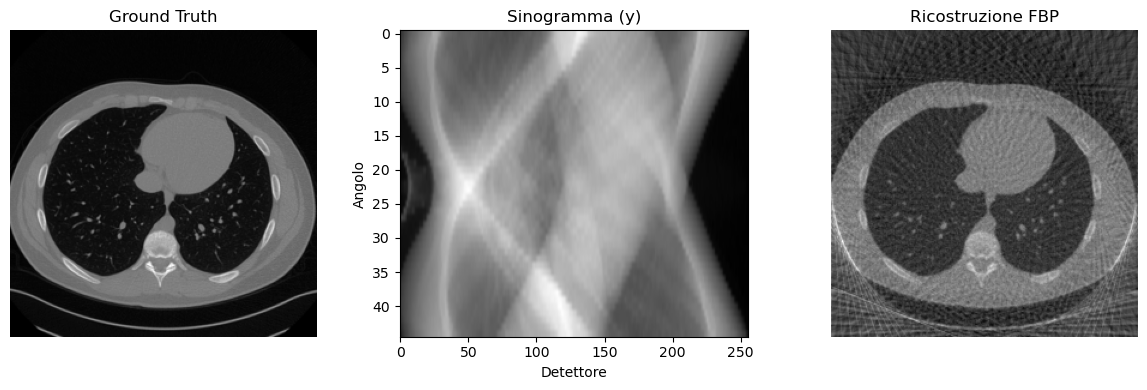

In [13]:
# METODO IPPY funzionante

# Load GT image
x_true = torch.from_numpy(np.load(train_images_npy[2])).unsqueeze(0).unsqueeze(0).float().to(device)
print(x_true.max())


K = operators_dict[n_angles]

# Compute noisy sinogram
y = K(x_true)  # Forward projection
y_delta = y + _utilities.gaussian_noise(y, noise_level=noise_level)

solver1=solvers.FBP(K)
x_sol,info = solver1(
    y_delta,
    x_true=x_true,
    starting_point=y_delta,
)


# Rimuovo le dimensioni batch/canale per visualizzare
x_true_img = x_true[0, 0].cpu().numpy()
x_sol_img = x_sol[0, 0].detach().cpu().numpy()
y_sino = y_delta[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Immagine ground truth
im0 = axes[0].imshow(x_true_img, cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

# Sinogramma
im1 = axes[1].imshow(y_sino, cmap="gray", aspect="auto")
axes[1].set_title("Sinogramma (y)")
axes[1].set_xlabel("Detettore")
axes[1].set_ylabel("Angolo")

# Soluzione ricostruita
im2 = axes[2].imshow(x_sol_img, cmap="gray")
axes[2].set_title("Ricostruzione FBP")
axes[2].axis("off")

plt.tight_layout()
plt.show()


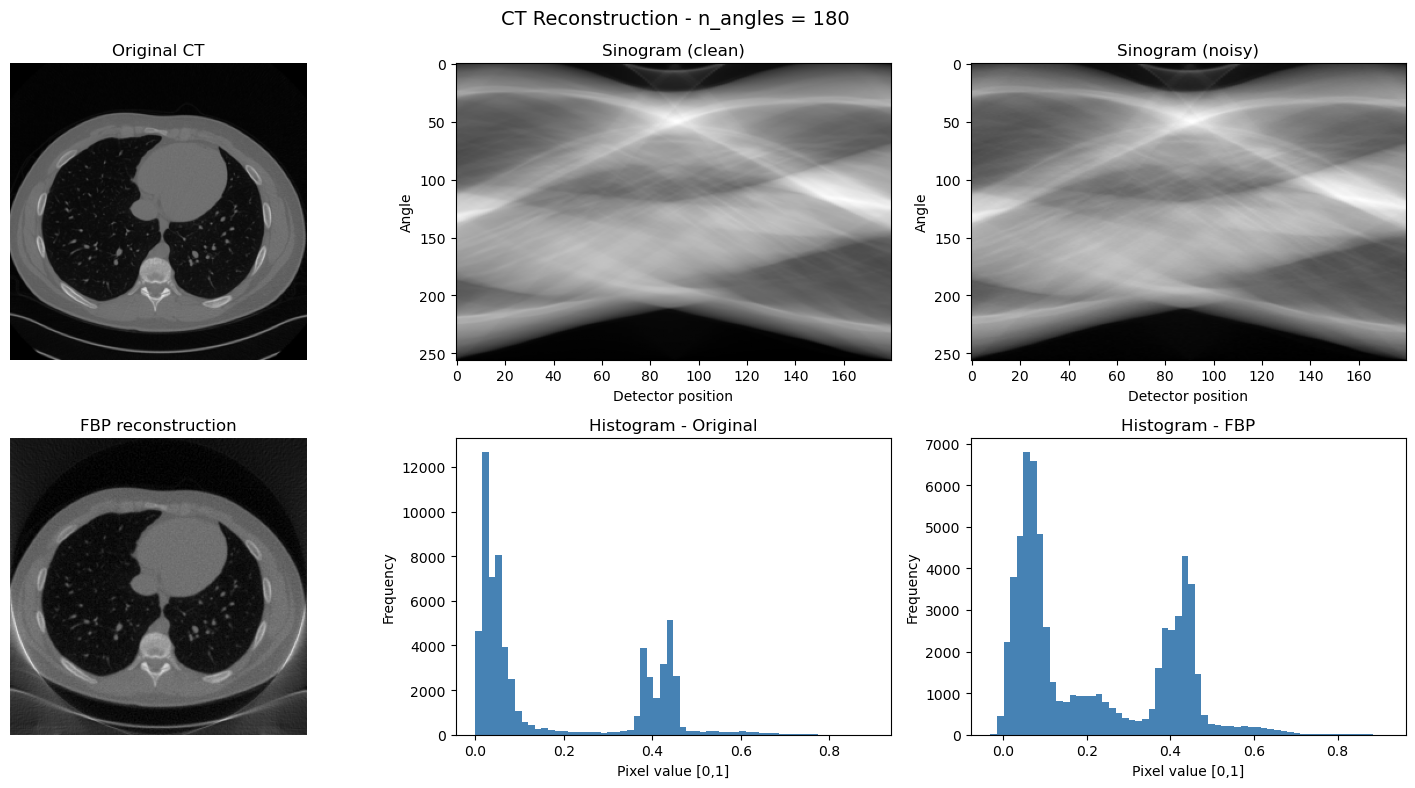

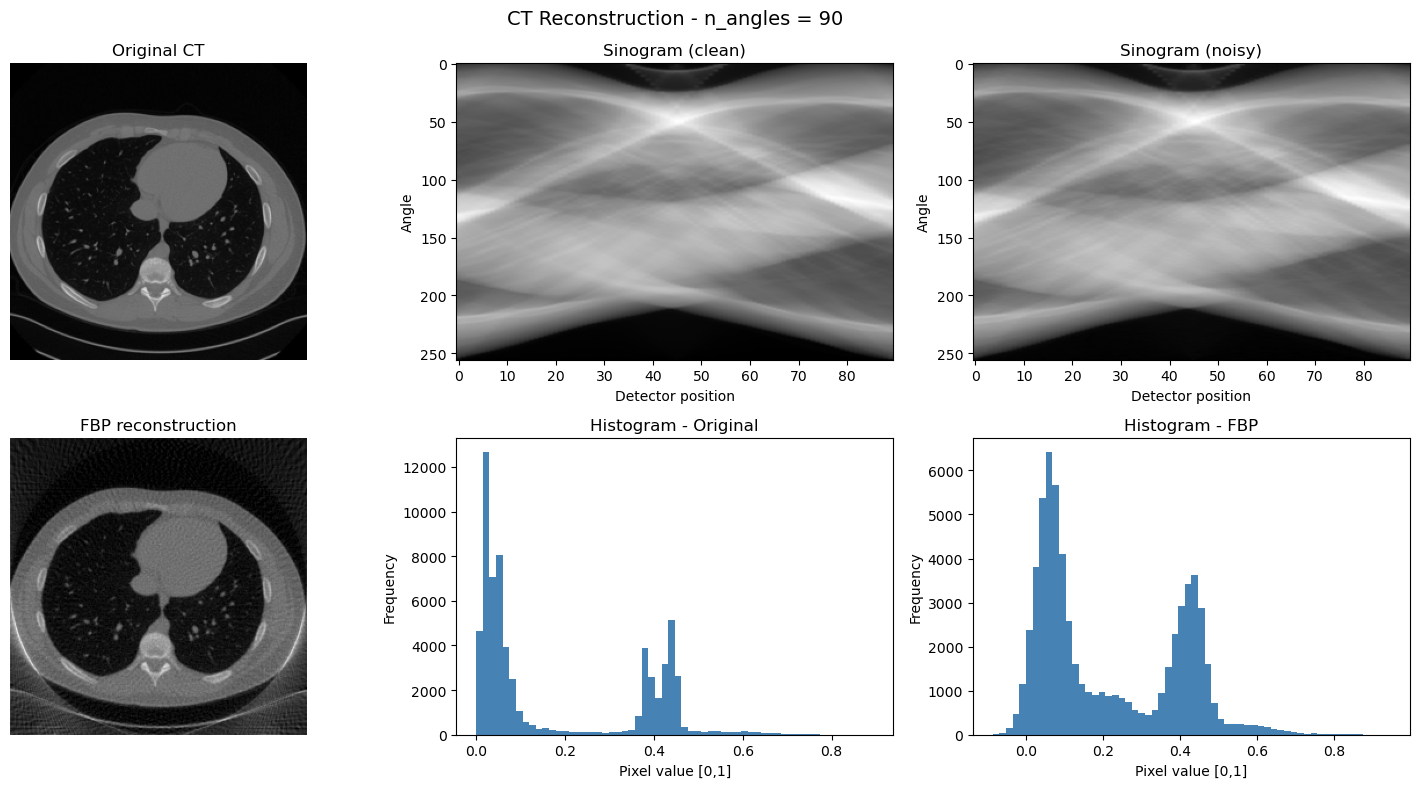

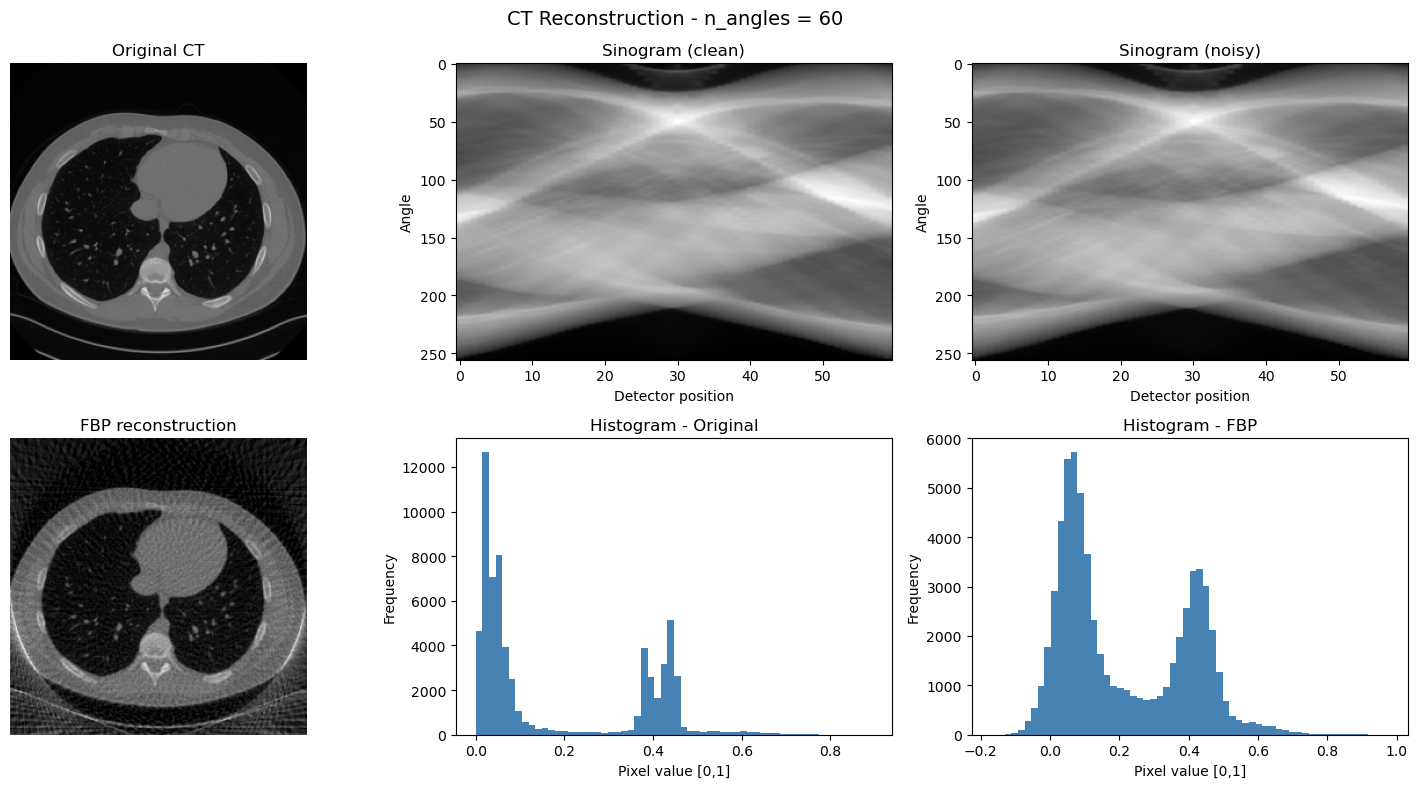

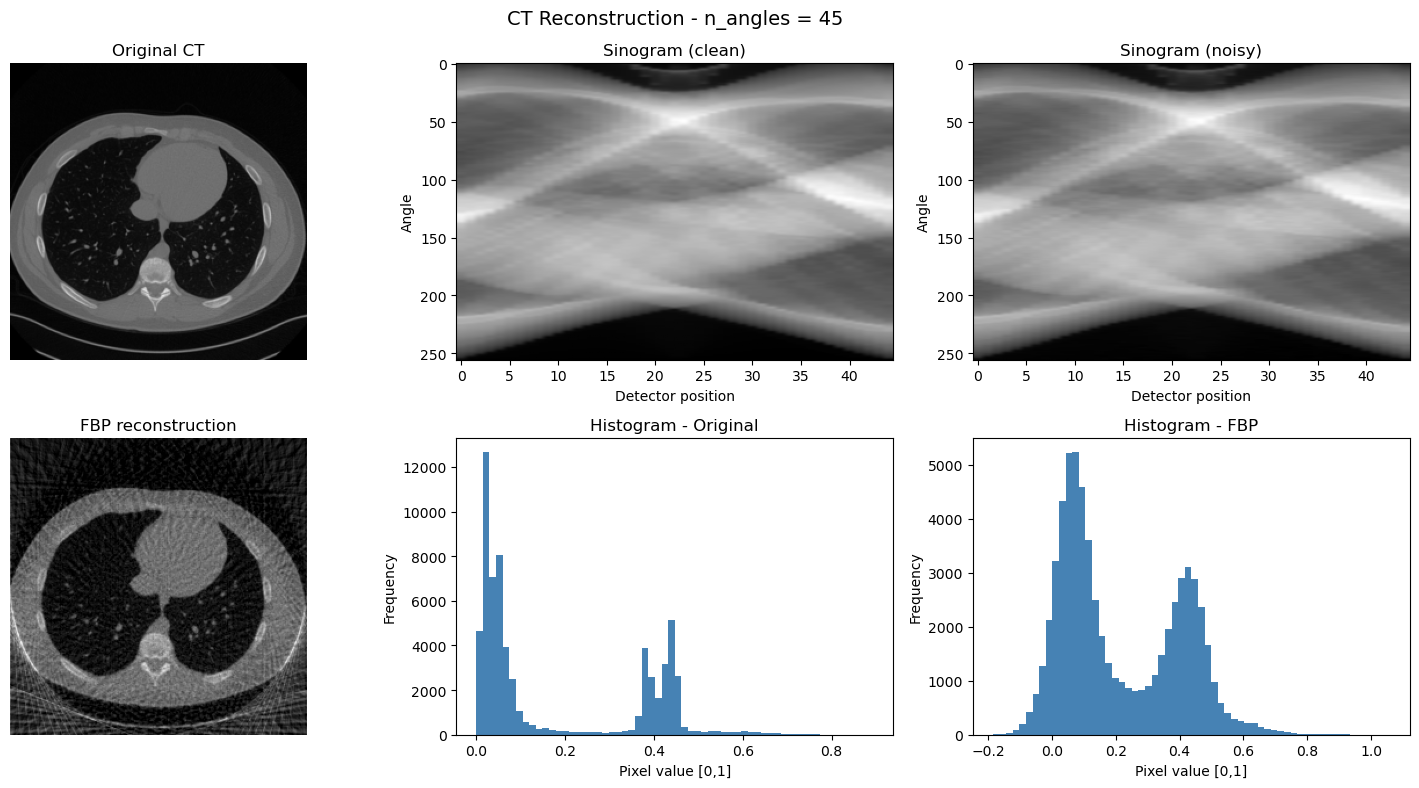

In [14]:
# ============================================================
# LOOP ANGLE CONFIGS
# ============================================================
for n_angles in ANGLE_CONFIGS:

    K = operators_dict[n_angles]

    y = K(x_true)
    y_delta = y + _utilities.gaussian_noise(y, noise_level=noise_level)

    solver1 = solvers.FBP(K)
    x_sol, info = solver1(y_delta, x_true=x_true, starting_point=y_delta)

    x_true_img = x_true[0, 0].cpu().numpy()
    x_sol_img = x_sol[0, 0].detach().cpu().numpy()
    y_clean = y[0, 0].cpu().numpy()
    y_noisy = y_delta[0, 0].cpu().numpy()

    orig_pixels = x_true_img.flatten()
    fbp_pixels = x_sol_img.flatten()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"CT Reconstruction - n_angles = {n_angles}", fontsize=14)

    axes[0, 0].imshow(x_true_img, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title("Original CT")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(y_clean.T, cmap='gray', aspect='auto')
    axes[0, 1].set_title("Sinogram (clean)")
    axes[0, 1].set_xlabel("Detector position")
    axes[0, 1].set_ylabel("Angle")

    axes[0, 2].imshow(y_noisy.T, cmap='gray', aspect='auto')
    axes[0, 2].set_title("Sinogram (noisy)")
    axes[0, 2].set_xlabel("Detector position")
    axes[0, 2].set_ylabel("Angle")

    axes[1, 0].imshow(x_sol_img, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title("FBP reconstruction")
    axes[1, 0].axis("off")

    axes[1, 1].hist(orig_pixels, bins=60, color='steelblue', edgecolor='none')
    axes[1, 1].set_title("Histogram - Original")
    axes[1, 1].set_xlabel("Pixel value [0,1]")
    axes[1, 1].set_ylabel("Frequency")

    axes[1, 2].hist(fbp_pixels, bins=60, color='steelblue', edgecolor='none')
    axes[1, 2].set_title("Histogram - FBP")
    axes[1, 2].set_xlabel("Pixel value [0,1]")
    axes[1, 2].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# SAVE SINOGRAMS
# ============================================================
def save_sinograms(image_paths, split_name):

    for img_path in image_paths:

        # carica immagine preprocessata
        img_np = np.load(img_path)   # (256, 256), float32, [0,1]
        img_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)

        # nome univoco basato sul path relativo
        rel_path = os.path.relpath(img_path, PREPROCESSED_PATH + f"/{split_name}")
        filename = os.path.splitext(rel_path.replace(os.sep, "_"))[0]

        for n_angles in ANGLE_CONFIGS:

            K = operators_dict[n_angles]

            # CLEAN SINOGRAM
            sinogram = K(img_tensor)
            sinogram_np = sinogram[0, 0].detach().cpu().numpy().astype(np.float32)

            # NOISY SINOGRAM
            noisy_sinogram = sinogram + _utilities.gaussian_noise(sinogram, noise_level=noise_level)
            noisy_np = noisy_sinogram[0, 0].detach().cpu().numpy().astype(np.float32)

            # SAVE PATHS
            clean_path = os.path.join(
                SINOGRAM_CLEAN_PATH,
                split_name,
                f"angles_{n_angles}",
                f"{filename}.npy"
            )
            noisy_path = os.path.join(
                SINOGRAM_CORRUPTED_PATH,
                split_name,
                f"angles_{n_angles}",
                f"{filename}.npy"
            )

            # SAVE
            np.save(clean_path, sinogram_np)
            np.save(noisy_path, noisy_np)

    print(f"Saved sinograms for {split_name}")

In [16]:
save_sinograms(train_images_npy, "train")
save_sinograms(val_images_npy,   "validation")
save_sinograms(test_images_npy,  "test")

KeyboardInterrupt: 

In [3]:
# RADON AND IRADON METHOD
'''
# carica un'immagine dal nuovo sistema
img_2d = np.load(train_images_npy[2])   # shape (256, 256), float32 [0,1]



for n_angles in ANGLE_CONFIGS:

    angles = np.linspace(0, 180, n_angles, endpoint=False)

    # =========================================================
    # FORWARD PROJECTION
    # =========================================================
    sinogram = radon(img_2d, theta=angles, circle=False)

    # =========================================================
    # ADD GAUSSIAN NOISE
    # =========================================================
    noisy_sinogram = sinogram + np.random.normal(
        0,
        noise_level * sinogram.max(),
        sinogram.shape
    )

    # =========================================================
    # FBP RECONSTRUCTION
    # =========================================================
    fbp = iradon(
        noisy_sinogram,
        theta=angles,
        filter_name='ramp',
        circle=False
    )
    fbp = np.clip(fbp, 0, 1)

    # =========================================================
    # PLOT
    # =========================================================
    orig_pixels = img_2d.flatten()
    fbp_pixels  = fbp.flatten()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"CT Reconstruction - n_angles = {n_angles}", fontsize=14)

    axes[0, 0].imshow(img_2d, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title("Original CT")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(sinogram, cmap='gray', aspect='auto')
    axes[0, 1].set_title("Sinogram (clean)")
    axes[0, 1].set_xlabel("Angle")

    axes[0, 2].imshow(noisy_sinogram, cmap='gray', aspect='auto')
    axes[0, 2].set_title("Sinogram (noisy)")
    axes[0, 2].set_xlabel("Angle")

    axes[1, 0].imshow(fbp, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title("FBP reconstruction")
    axes[1, 0].axis("off")

    axes[1, 1].hist(orig_pixels, bins=60, color='steelblue', edgecolor='none')
    axes[1, 1].set_title("Histogram - Original")
    axes[1, 1].set_xlabel("Pixel value [0,1]")
    axes[1, 1].set_ylabel("Frequency")

    axes[1, 2].hist(fbp_pixels, bins=60, color='steelblue', edgecolor='none')
    axes[1, 2].set_title("Histogram - FBP")
    axes[1, 2].set_xlabel("Pixel value [0,1]")
    axes[1, 2].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# FILTER COMPARISON
# ============================================================
noise_level = 0.005
n_angles    = 45
filters     = ['ramp', 'shepp-logan', 'cosine', 'hamming', 'hann', None]

angles = np.linspace(0, 180, n_angles, endpoint=False)

sinogram       = radon(img_2d, theta=angles, circle=False)
noisy_sinogram = sinogram + np.random.normal(0, noise_level * sinogram.max(), sinogram.shape)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle(f"FBP Filter Comparison ({n_angles} angles)", fontsize=15)

axes[0, 0].imshow(img_2d, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("Original CT")
axes[0, 0].axis("off")

axes[0, 1].imshow(noisy_sinogram, cmap='gray', aspect='auto')
axes[0, 1].set_title("Noisy sinogram")
axes[0, 1].set_xlabel("Angle")

axes[0, 2].axis("off")

for idx, filt in enumerate(filters[:3]):
    row, col = 1, idx
    recon = iradon(noisy_sinogram, theta=angles, filter_name=filt, circle=False)
    recon = np.clip(recon, 0, 1)
    axes[row, col].imshow(recon, cmap='gray', vmin=0, vmax=1)
    axes[row, col].set_title(filt)
    axes[row, col].axis("off")
for idx, filt in enumerate(filters[3:7]):
    row, col = 2, idx
    recon = iradon(noisy_sinogram, theta=angles, filter_name=filt, circle=False)
    
    # normalizza invece di clippare solo per None
    if filt is None:
        recon = (recon - recon.min()) / (recon.max() - recon.min())
        title = "No filter (backprojection)"
    else:
        recon = np.clip(recon, 0, 1)
        title = filt
    
    axes[row, col].imshow(recon, cmap='gray', vmin=0, vmax=1)
    axes[row, col].set_title(title)
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()
'''

'\n# carica un\'immagine dal nuovo sistema\nimg_2d = np.load(train_images_npy[2])   # shape (256, 256), float32 [0,1]\n\n\n\nfor n_angles in ANGLE_CONFIGS:\n\n    angles = np.linspace(0, 180, n_angles, endpoint=False)\n\n    # =========================================================\n    # FORWARD PROJECTION\n    # =========================================================\n    sinogram = radon(img_2d, theta=angles, circle=False)\n\n    # =========================================================\n    # ADD GAUSSIAN NOISE\n    # =========================================================\n    noisy_sinogram = sinogram + np.random.normal(\n        0,\n        noise_level * sinogram.max(),\n        sinogram.shape\n    )\n\n    # =========================================================\n    # FBP RECONSTRUCTION\n    # =========================================================\n    fbp = iradon(\n        noisy_sinogram,\n        theta=angles,\n        filter_name=\'ramp\',\n        circle=Fal

In [6]:
# Metodo IPPy, primo tentativo
'''
from ippy import operators, solvers
from ippy.metrics import SSIM, PSNR, RE
import torch

noise_level = 0
ANGLE_CONFIGS = [180, 90, 60, 45]

# carica l'immagine dal nuovo sistema
img_2d = torch.from_numpy(np.load(train_images_npy[0])).unsqueeze(0).unsqueeze(0)  # [1, 1, 256, 256]

for n_angles in ANGLE_CONFIGS:

    angles = np.linspace(0, np.pi, n_angles, endpoint=True)

    print(f"Dimensioni di img_2d: {img_2d.shape}")
    print(f"Numero totale di elementi: {img_2d.numel()}")

    K = operators.CTProjector(
        img_shape=(256, 256),
        angles=angles,
        det_size=256,
        geometry="parallel"
    )

    sinogram       = K(img_2d)
    ampiezza_rumore = noise_level * sinogram.max()
    sinogram_noisy  = sinogram + ampiezza_rumore * torch.randn_like(sinogram)

    solver1 = solvers.FBP(K)
    x_sol, info = solver1(
        sinogram_noisy,
        x_true=img_2d,
        starting_point=sinogram_noisy
    )

    # per il plot usa squeeze() senza sovrascrivere img_2d
    img_plot      = img_2d.squeeze()
    sino_plot     = sinogram.squeeze()
    sino_noisy_plot = sinogram_noisy.squeeze()
    recon_plot    = x_sol.squeeze()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"n_angles = {n_angles}", fontsize=13)

    axes[0].imshow(img_plot, cmap=plt.cm.Greys_r, vmin=0, vmax=1)
    axes[0].set_title("Original")
    axes[0].axis("off")



    axes[1].imshow(sino_plot.T, cmap=plt.cm.Greys_r, aspect='auto')
    axes[1].set_title("Sinogram (clean)")
    axes[1].set_xlabel("Angle (deg)")

    axes[2].imshow(sino_noisy_plot.T, cmap=plt.cm.Greys_r, aspect='auto')
    axes[2].set_title("Sinogram (noisy)")
    axes[2].set_xlabel("Angle (deg)")

    axes[3].imshow(recon_plot, cmap=plt.cm.Greys_r)
    axes[3].set_title("FBP reconstruction")
    axes[3].axis("off")

    fig.tight_layout()
    plt.show()
    '''

'\nfrom ippy import operators, solvers\nfrom ippy.metrics import SSIM, PSNR, RE\nimport torch\n\nnoise_level = 0\nANGLE_CONFIGS = [180, 90, 60, 45]\n\n# carica l\'immagine dal nuovo sistema\nimg_2d = torch.from_numpy(np.load(train_images_npy[0])).unsqueeze(0).unsqueeze(0)  # [1, 1, 256, 256]\n\nfor n_angles in ANGLE_CONFIGS:\n\n    angles = np.linspace(0, np.pi, n_angles, endpoint=True)\n\n    print(f"Dimensioni di img_2d: {img_2d.shape}")\n    print(f"Numero totale di elementi: {img_2d.numel()}")\n\n    K = operators.CTProjector(\n        img_shape=(256, 256),\n        angles=angles,\n        det_size=256,\n        geometry="parallel"\n    )\n\n    sinogram       = K(img_2d)\n    ampiezza_rumore = noise_level * sinogram.max()\n    sinogram_noisy  = sinogram + ampiezza_rumore * torch.randn_like(sinogram)\n\n    solver1 = solvers.FBP(K)\n    x_sol, info = solver1(\n        sinogram_noisy,\n        x_true=img_2d,\n        starting_point=sinogram_noisy\n    )\n\n    # per il plot usa sque